<a href="https://www.kaggle.com/code/sonawanelalitsunil/india-road-accident-prediction-analysis-ml-34?scriptVersionId=234329613" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/india-road-accident-dataset-predictive-analysis/accident_prediction_india.csv


## Title: India Road Accident Prediction Analysis

#### Description: This project analyzes road accident data in India to predict accident occurrence based on factors like location, time, weather, and road conditions. The goal is to identify patterns and develop predictive models to enhance road safety and inform decision-making for traffic management.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/india-road-accident-dataset-predictive-analysis/accident_prediction_india.csv')

In [3]:
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [4]:
df.tail()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
2995,Tamil Nadu,Chennai,2021,January,Sunday,1:15,Minor,5,Truck,4,...,National Highway,Wet,Dark,Signs,74,43,Male,Expired,Yes,Intersection
2996,Uttarakhand,Unknown,2018,July,Sunday,10:12,Fatal,3,Car,3,...,Urban Road,Under Construction,Daylight,NaN,86,23,Female,NaN,Yes,Intersection
2997,Meghalaya,Unknown,2021,January,Thursday,19:34,Minor,2,Two-Wheeler,8,...,National Highway,Dry,Dark,Signs,47,57,Female,Valid,Yes,Intersection
2998,Meghalaya,Unknown,2023,June,Sunday,20:54,Fatal,1,Cycle,9,...,Urban Road,Under Construction,Daylight,Signs,60,28,Female,Expired,Yes,Bridge
2999,Arunachal Pradesh,Unknown,2020,September,Monday,7:19,Fatal,5,Cycle,1,...,National Highway,Under Construction,Daylight,NaN,40,66,Male,NaN,Yes,Bridge


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

In [6]:
df.isnull().sum()

State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64

In [7]:
df.describe()

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2020.530000,2.996000,5.066000,2.455333,74.940667,44.17700
std,1.683858,1.428285,3.214097,1.717650,26.765088,15.40286
min,2018.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2019.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2021.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2022.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2023.000000,5.000000,10.000000,5.000000,120.000000,70.00000


In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(3000, 22)

In [10]:
df.dtypes

State Name                     object
City Name                      object
Year                            int64
Month                          object
Day of Week                    object
Time of Day                    object
Accident Severity              object
Number of Vehicles Involved     int64
Vehicle Type Involved          object
Number of Casualties            int64
Number of Fatalities            int64
Weather Conditions             object
Road Type                      object
Road Condition                 object
Lighting Conditions            object
Traffic Control Presence       object
Speed Limit (km/h)              int64
Driver Age                      int64
Driver Gender                  object
Driver License Status          object
Alcohol Involvement            object
Accident Location Details      object
dtype: object

In [11]:
df.columns

Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement', 'Accident Location Details'],
      dtype='object')

## Data visualizations

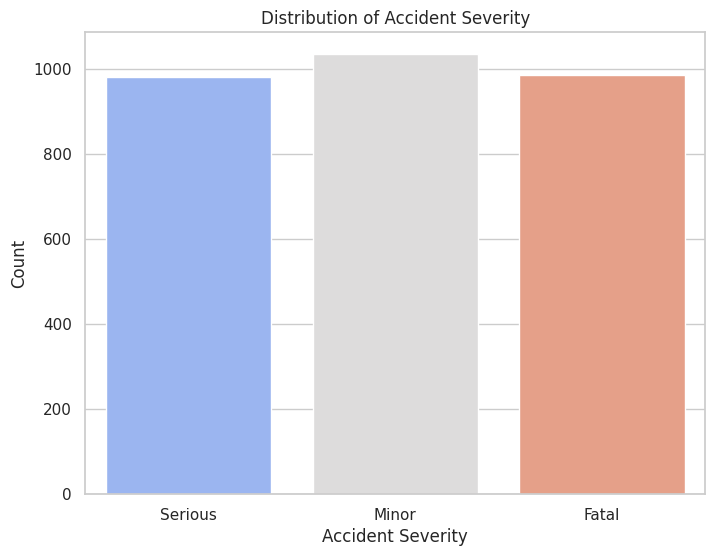

In [12]:
# Set the style for the plots
sns.set(style="whitegrid")

# 1. Distribution of Accident Severity
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Accident Severity', palette='coolwarm')
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

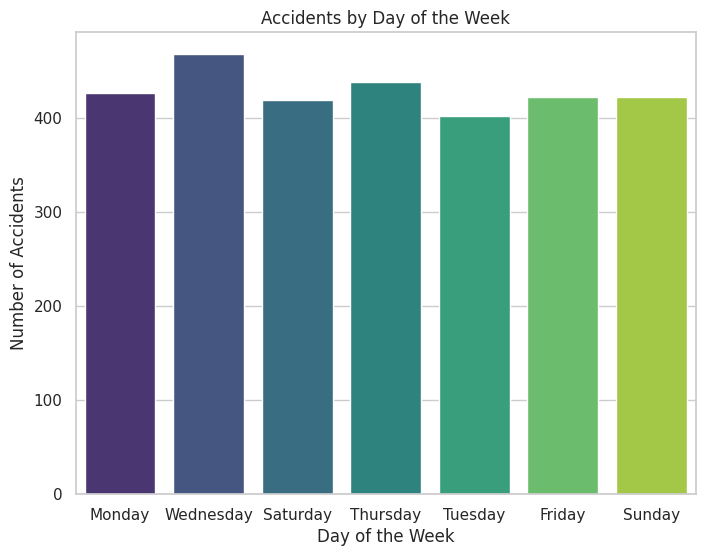

In [13]:
# 2. Number of Accidents by Day of the Week
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Day of Week', palette='viridis')
plt.title('Accidents by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Accidents')
plt.show()

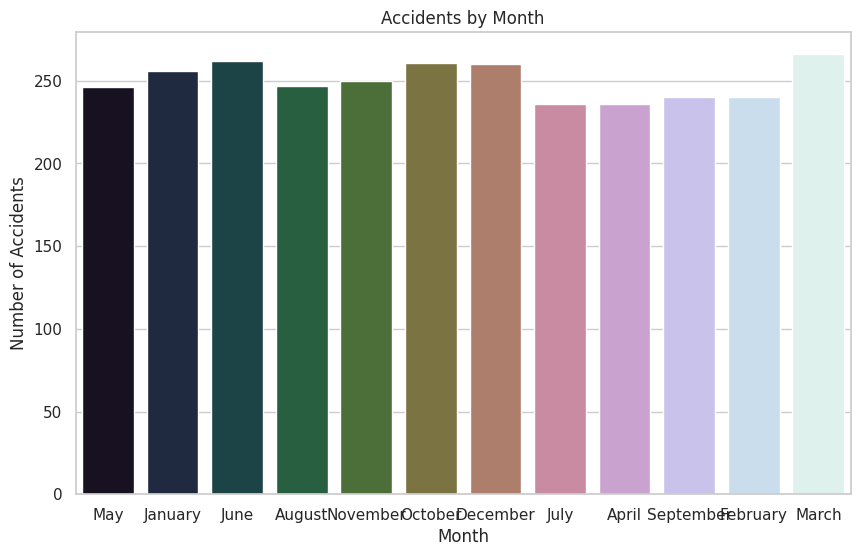

In [14]:
# 3. Number of Accidents by Month
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Month', palette='cubehelix')
plt.title('Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()


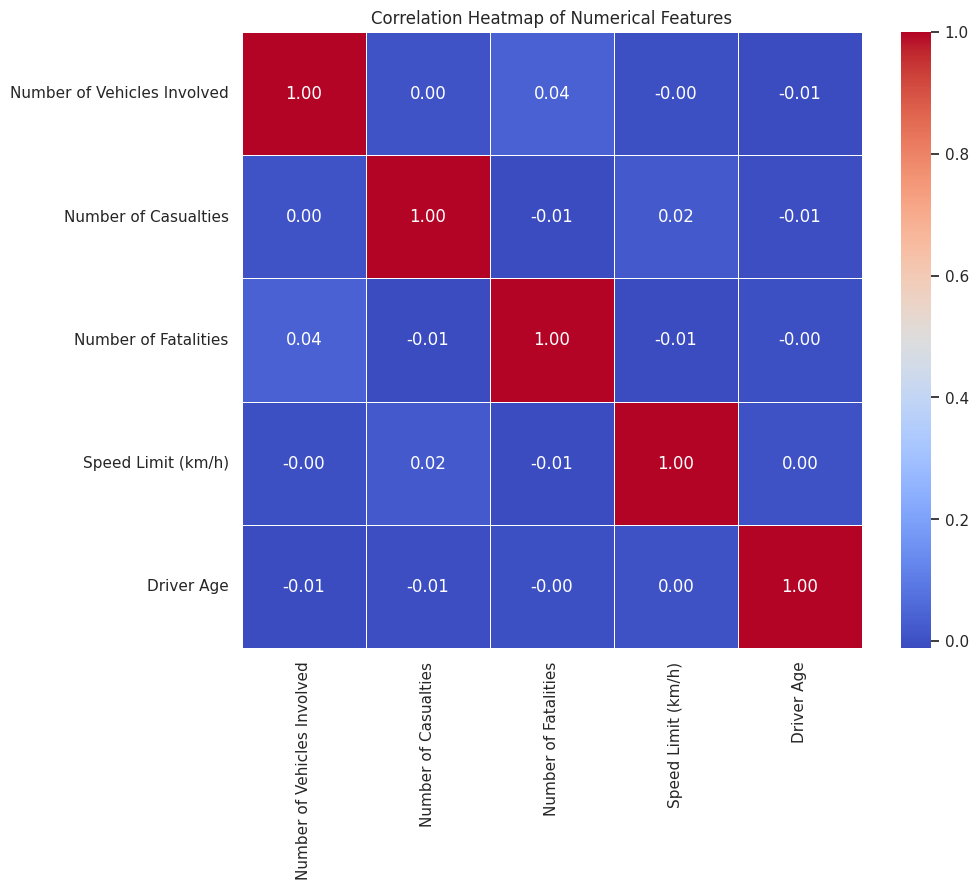

In [15]:
# 4. Correlation Heatmap of Numerical Features
numerical_features = ['Number of Vehicles Involved', 'Number of Casualties', 'Number of Fatalities',
                      'Speed Limit (km/h)', 'Driver Age']
plt.figure(figsize=(10, 8))
correlation = df[numerical_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

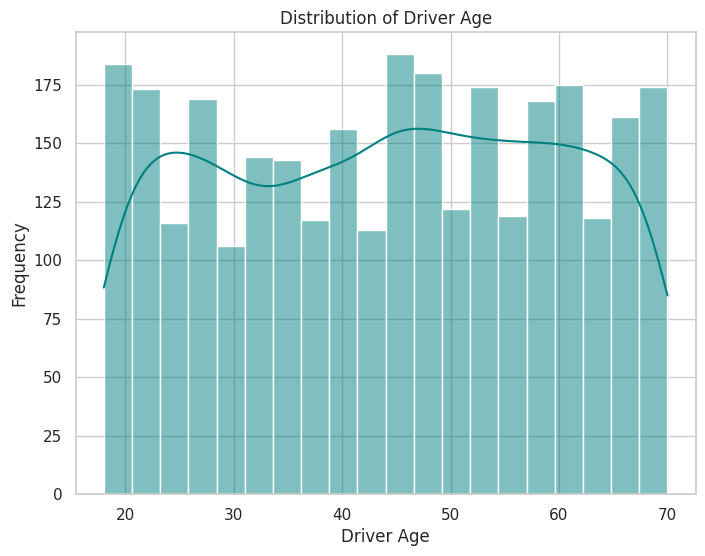

In [16]:
# 5. Distribution of Driver Age
plt.figure(figsize=(8, 6))
sns.histplot(df['Driver Age'], kde=True, color='teal', bins=20)
plt.title('Distribution of Driver Age')
plt.xlabel('Driver Age')
plt.ylabel('Frequency')
plt.show()


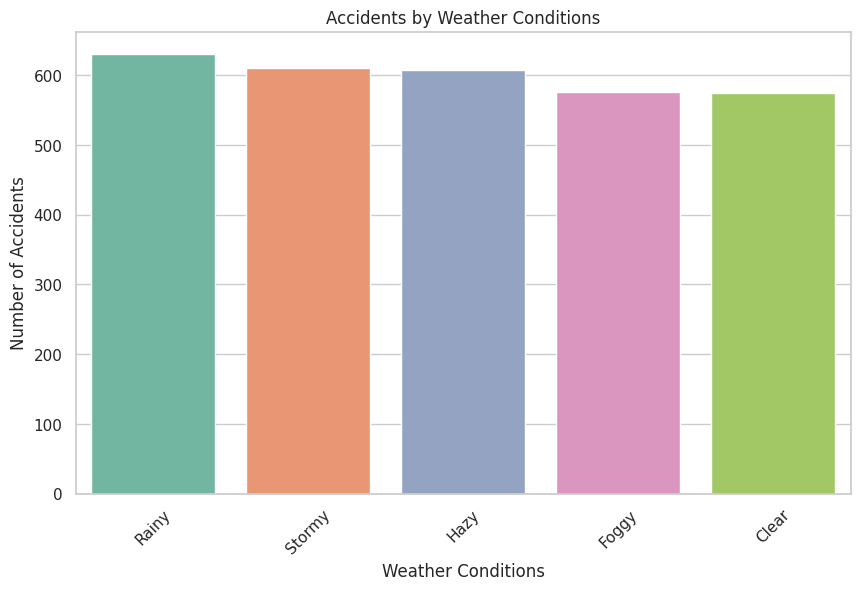

In [17]:
# 6. Number of Accidents by Weather Conditions
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Weather Conditions', palette='Set2', order=df['Weather Conditions'].value_counts().index)
plt.title('Accidents by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

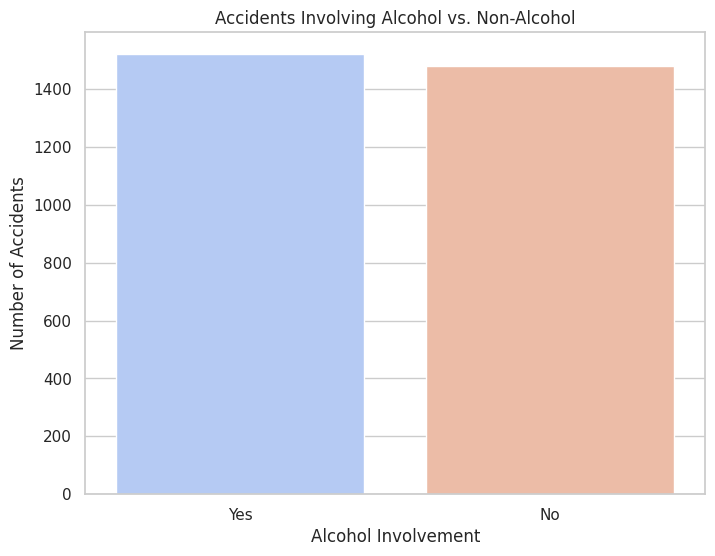

In [18]:
# 7. Accidents Involving Alcohol vs. Non-Alcohol
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Alcohol Involvement', palette='coolwarm')
plt.title('Accidents Involving Alcohol vs. Non-Alcohol')
plt.xlabel('Alcohol Involvement')
plt.ylabel('Number of Accidents')
plt.show()

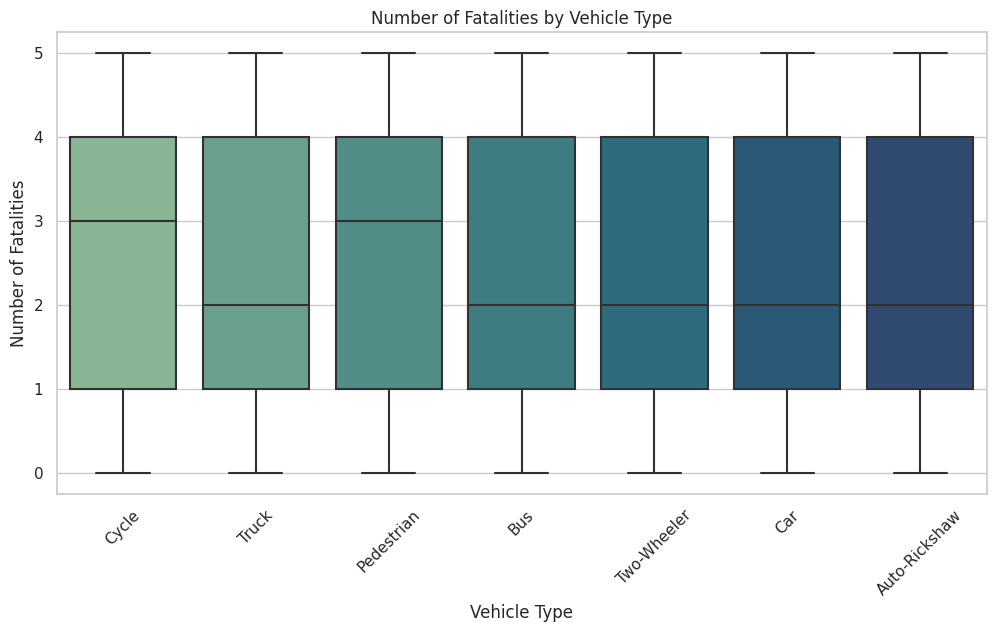

In [19]:
# 8. Number of Fatalities by Vehicle Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Vehicle Type Involved', y='Number of Fatalities', palette='crest')
plt.title('Number of Fatalities by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Fatalities')
plt.xticks(rotation=45)
plt.show()

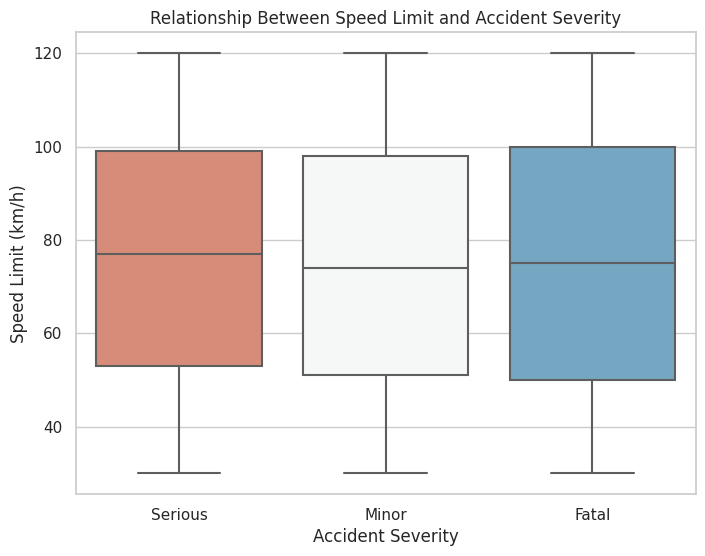

In [20]:
# 9. Relationship Between Speed Limit and Accident Severity
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Accident Severity', y='Speed Limit (km/h)', palette='RdBu')
plt.title('Relationship Between Speed Limit and Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Speed Limit (km/h)')
plt.show()


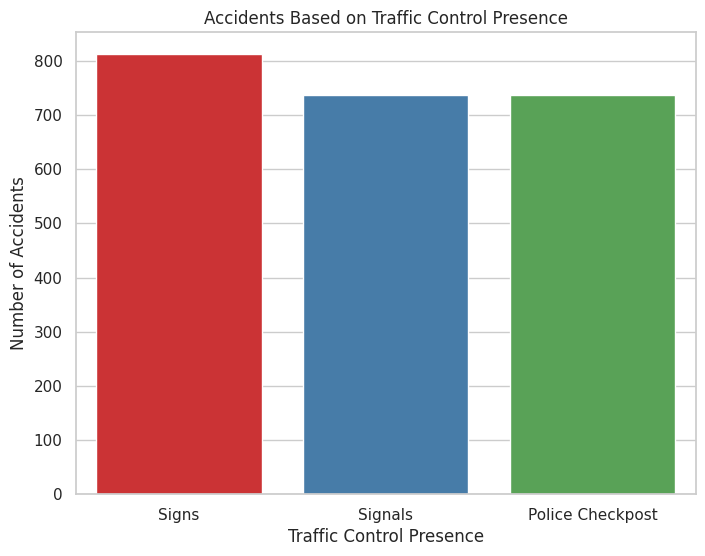

In [21]:
# 10. Accidents Based on Traffic Control Presence
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Traffic Control Presence', palette='Set1')
plt.title('Accidents Based on Traffic Control Presence')
plt.xlabel('Traffic Control Presence')
plt.ylabel('Number of Accidents')
plt.show()

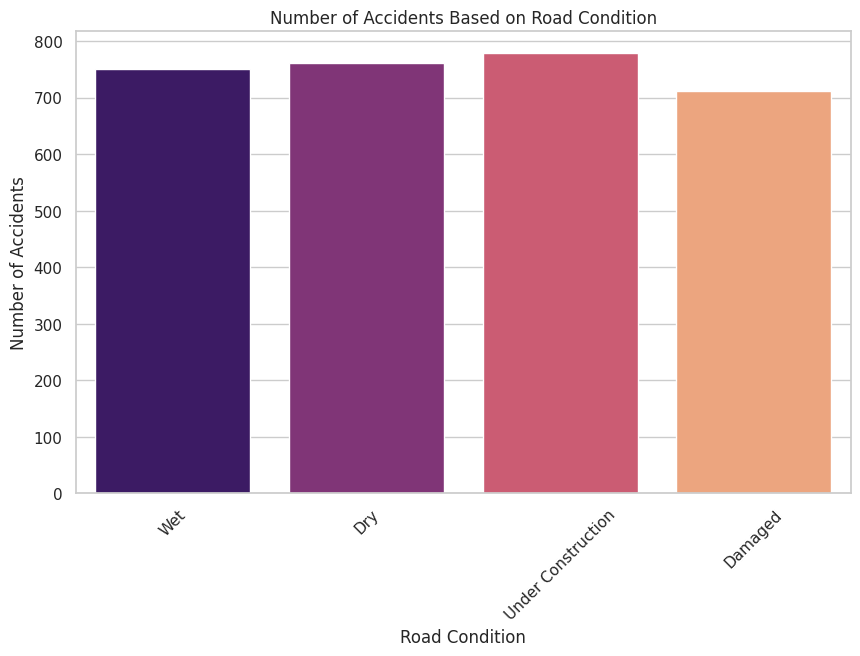

In [22]:
# 11. Number of Accidents Based on Road Condition
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Road Condition', palette='magma')
plt.title('Number of Accidents Based on Road Condition')
plt.xlabel('Road Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

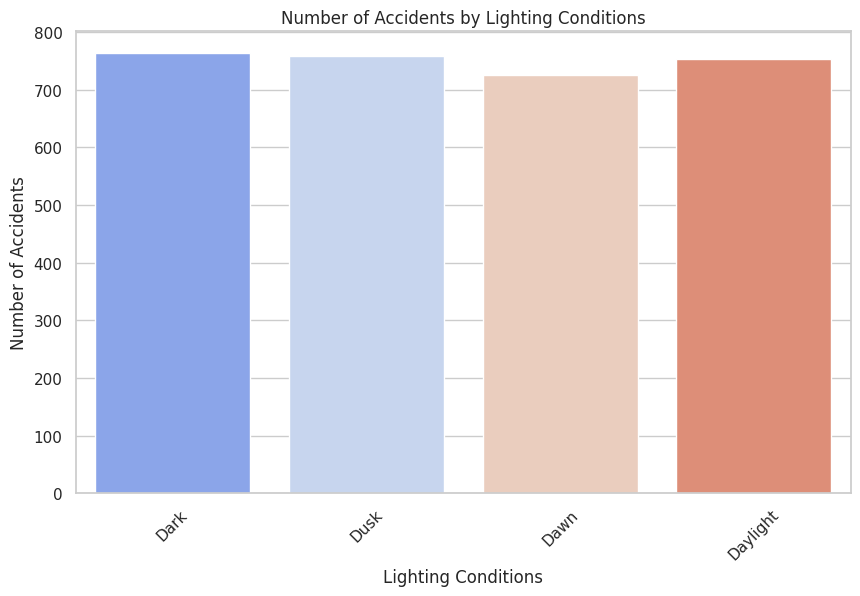

In [23]:
# 12. Number of Accidents by Lighting Conditions
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Lighting Conditions', palette='coolwarm')
plt.title('Number of Accidents by Lighting Conditions')
plt.xlabel('Lighting Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

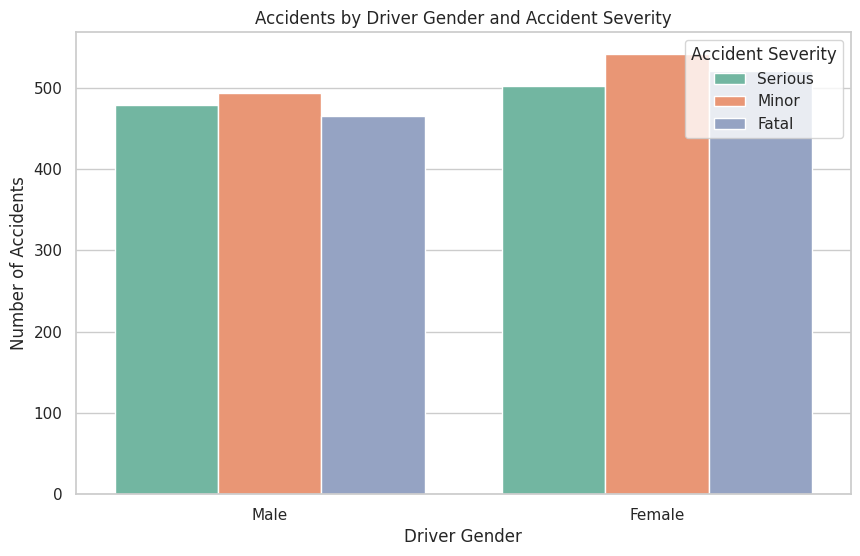

In [24]:
# 13. Number of Accidents by Driver Gender and Accident Severity
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Driver Gender', hue='Accident Severity', palette='Set2')
plt.title('Accidents by Driver Gender and Accident Severity')
plt.xlabel('Driver Gender')
plt.ylabel('Number of Accidents')
plt.show()

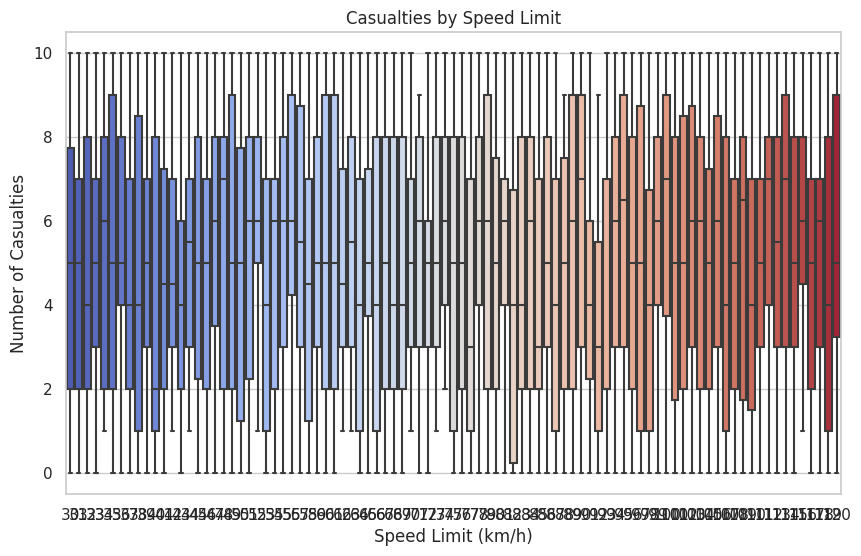

In [25]:
# 14. Boxplot of Casualties by Speed Limit
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Speed Limit (km/h)', y='Number of Casualties', palette='coolwarm')
plt.title('Casualties by Speed Limit')
plt.xlabel('Speed Limit (km/h)')
plt.ylabel('Number of Casualties')
plt.show()

## Predictive modeling

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


In [27]:
# Step 1: Drop rows with missing target or irrelevant columns if needed
df.dropna(subset=["Accident Severity"], inplace=True)

In [28]:
# Step 2: Handle missing values (simple imputation or drop)
df.fillna(method='ffill', inplace=True)


In [29]:
# Step 3: Encode categorical variables using LabelEncoder
label_encoders = {}
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [30]:
# Step 4: Define features and target
X = df.drop("Accident Severity", axis=1)
y = df["Accident Severity"]


In [31]:
# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
# Step 6: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}


📊 Logistic Regression


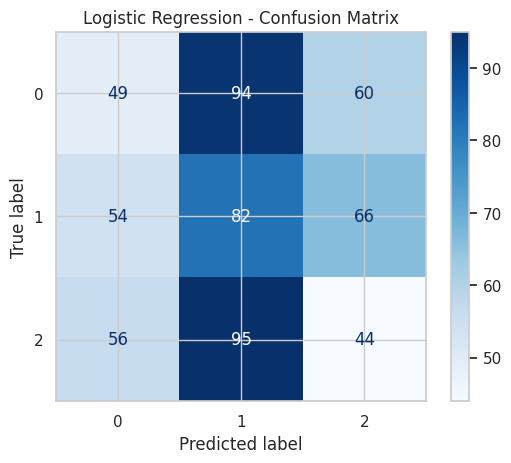

              precision    recall  f1-score   support

           0       0.31      0.24      0.27       203
           1       0.30      0.41      0.35       202
           2       0.26      0.23      0.24       195

    accuracy                           0.29       600
   macro avg       0.29      0.29      0.29       600
weighted avg       0.29      0.29      0.29       600


📊 Decision Tree


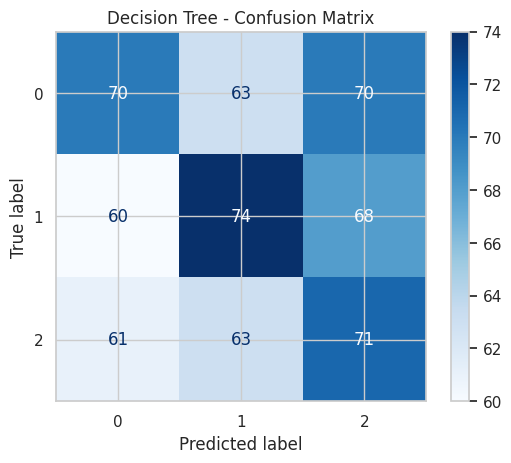

              precision    recall  f1-score   support

           0       0.37      0.34      0.36       203
           1       0.37      0.37      0.37       202
           2       0.34      0.36      0.35       195

    accuracy                           0.36       600
   macro avg       0.36      0.36      0.36       600
weighted avg       0.36      0.36      0.36       600


📊 Random Forest


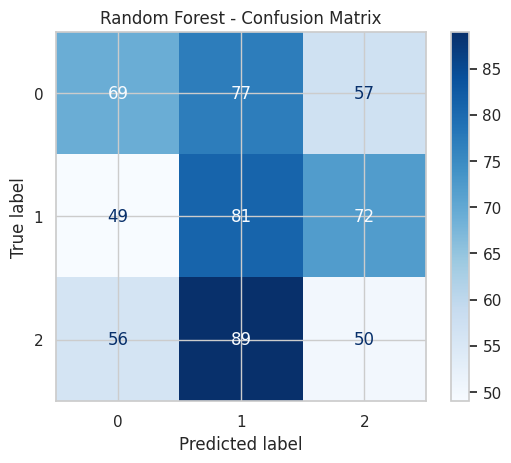

              precision    recall  f1-score   support

           0       0.40      0.34      0.37       203
           1       0.33      0.40      0.36       202
           2       0.28      0.26      0.27       195

    accuracy                           0.33       600
   macro avg       0.33      0.33      0.33       600
weighted avg       0.34      0.33      0.33       600


📊 SVM


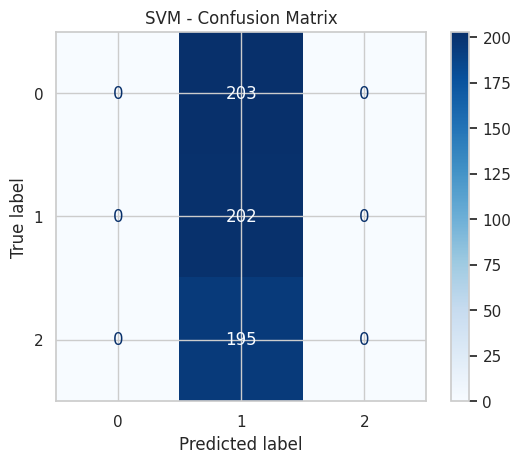

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       203
           1       0.34      1.00      0.50       202
           2       0.00      0.00      0.00       195

    accuracy                           0.34       600
   macro avg       0.11      0.33      0.17       600
weighted avg       0.11      0.34      0.17       600


📊 KNN


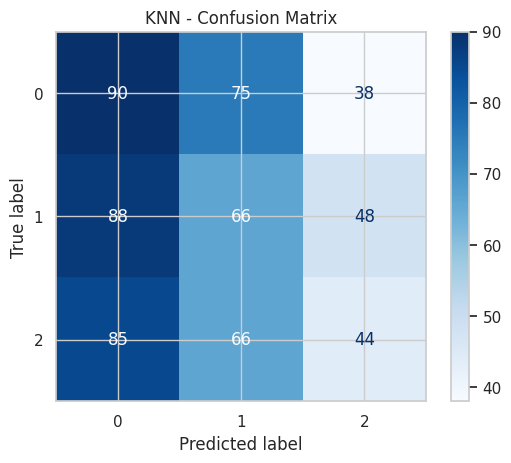

              precision    recall  f1-score   support

           0       0.34      0.44      0.39       203
           1       0.32      0.33      0.32       202
           2       0.34      0.23      0.27       195

    accuracy                           0.33       600
   macro avg       0.33      0.33      0.33       600
weighted avg       0.33      0.33      0.33       600


📊 XGBoost


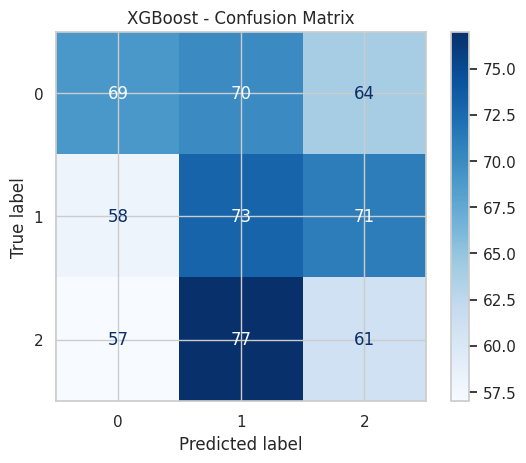

              precision    recall  f1-score   support

           0       0.38      0.34      0.36       203
           1       0.33      0.36      0.35       202
           2       0.31      0.31      0.31       195

    accuracy                           0.34       600
   macro avg       0.34      0.34      0.34       600
weighted avg       0.34      0.34      0.34       600



In [33]:
# Step 7: Train and evaluate models
for name, model in models.items():
    print(f"\n📊 {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    # Classification report
    print(classification_report(y_test, y_pred))

## THank you..pls upvote!!!